# Customer Churn Prediction
# End-to-End Machine Learning Project

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)
import joblib
import warnings
warnings.filterwarnings('ignore')

In [104]:
data = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [105]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [106]:
data.shape

(7043, 21)

In [107]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [108]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [109]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [110]:
data.describe(include="all")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [111]:
data["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [112]:
data["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.463013
Yes,26.536987


In [113]:
data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [114]:
data.nunique().sort_values(ascending=False)

,0
customerID,7043
TotalCharges,6531
MonthlyCharges,1585
tenure,73
PaymentMethod,4
StreamingMovies,3
TechSupport,3
OnlineBackup,3
StreamingTV,3
DeviceProtection,3


In [115]:
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")

In [116]:
data["TotalCharges"].dtype

dtype('float64')

In [117]:
data["TotalCharges"].isnull().sum()

np.int64(11)

In [118]:
data[data['TotalCharges'].isnull()][
    ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
]

,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,NaN,No
753,0,20.25,NaN,No
936,0,80.85,NaN,No
1082,0,25.75,NaN,No
1340,0,56.05,NaN,No
3331,0,19.85,NaN,No
3826,0,25.35,NaN,No
4380,0,20.00,NaN,No
5218,0,19.70,NaN,No
6670,0,73.35,NaN,No


In [119]:
data[data['tenure'] == 0][
    ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
]

,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,NaN,No
753,0,20.25,NaN,No
936,0,80.85,NaN,No
1082,0,25.75,NaN,No
1340,0,56.05,NaN,No
3331,0,19.85,NaN,No
3826,0,25.35,NaN,No
4380,0,20.00,NaN,No
5218,0,19.70,NaN,No
6670,0,73.35,NaN,No


In [120]:
data[data['tenure'] == 0].shape

(11, 21)

In [121]:
data['TotalCharges'] = data['TotalCharges'].fillna(0)

In [122]:
data['TotalCharges'].isnull().sum()

np.int64(0)

In [123]:
data.duplicated().sum()

np.int64(0)

In [124]:
data["customerID"].nunique()

7043

In [125]:
data.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [126]:
for col in data.select_dtypes(include='object').columns:
    print(f"\n{col}:")
    print(data[col].unique())


customerID:
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

gender:
['Female' 'Male']

Partner:
['Yes' 'No']

Dependents:
['No' 'Yes']

PhoneService:
['No' 'Yes']

MultipleLines:
['No phone service' 'No' 'Yes']

InternetService:
['DSL' 'Fiber optic' 'No']

OnlineSecurity:
['No' 'Yes' 'No internet service']

OnlineBackup:
['Yes' 'No' 'No internet service']

DeviceProtection:
['No' 'Yes' 'No internet service']

TechSupport:
['No' 'Yes' 'No internet service']

StreamingTV:
['No' 'Yes' 'No internet service']

StreamingMovies:
['No' 'Yes' 'No internet service']

Contract:
['Month-to-month' 'One year' 'Two year']

PaperlessBilling:
['Yes' 'No']

PaymentMethod:
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

Churn:
['No' 'Yes']


In [127]:
cleaned_data = data.copy()

In [128]:
data_eda = cleaned_data.copy()

In [129]:
for column in cleaned_data.select_dtypes(include="object").columns:
    spaces = cleaned_data[column].astype(str).str.strip().ne(cleaned_data[column].astype(str)).sum()
    if spaces > 0:
        print(column, spaces)

In [130]:
data_eda.shape

(7043, 21)

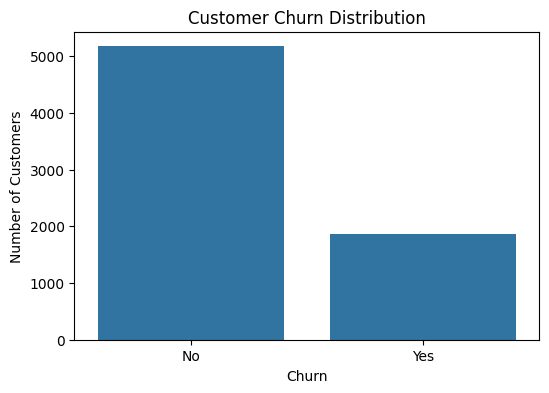

In [131]:
plt.figure(figsize=(6, 4))

sns.countplot(data=data_eda, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [132]:
churn_percentage = data_eda["Churn"].value_counts(normalize=True) * 100

print(churn_percentage)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


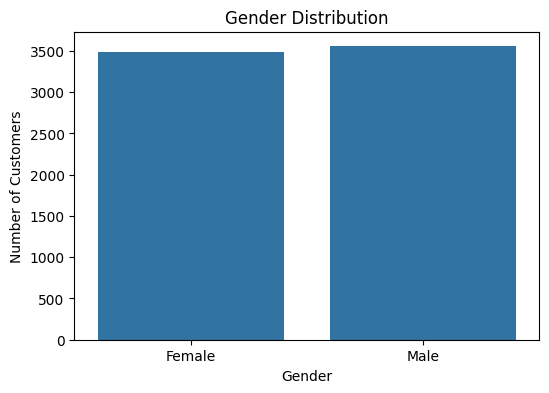

In [133]:
plt.figure(figsize=(6, 4))

sns.countplot(data=data_eda, x="gender")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

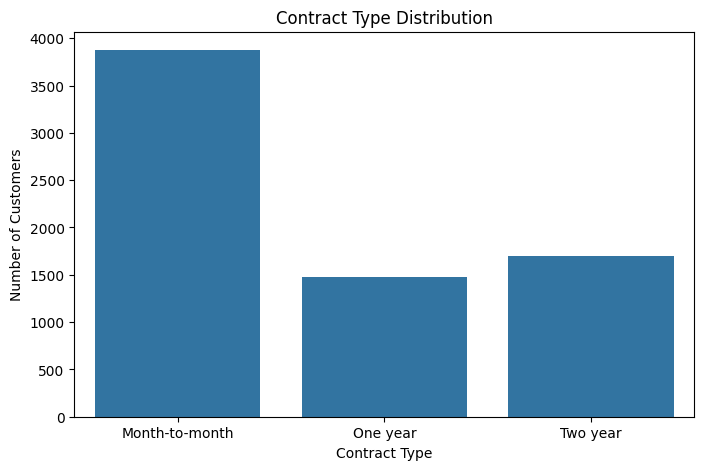

In [134]:
plt.figure(figsize=(8, 5))

sns.countplot(data=data_eda, x="Contract")

plt.title("Contract Type Distribution")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

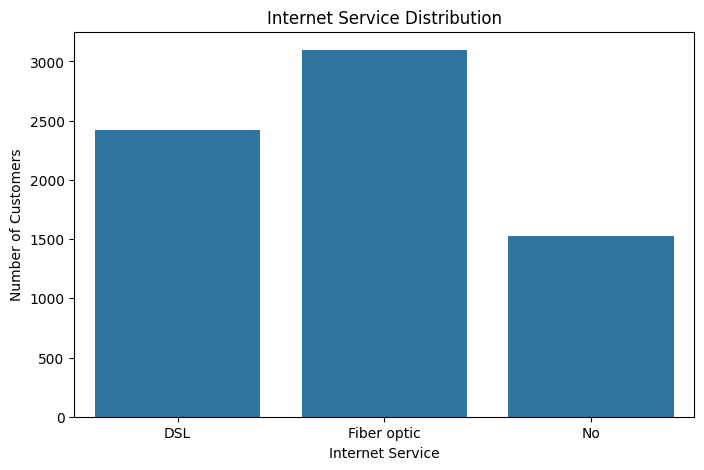

In [135]:
plt.figure(figsize=(8, 5))

sns.countplot(data=data_eda, x="InternetService")

plt.title("Internet Service Distribution")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

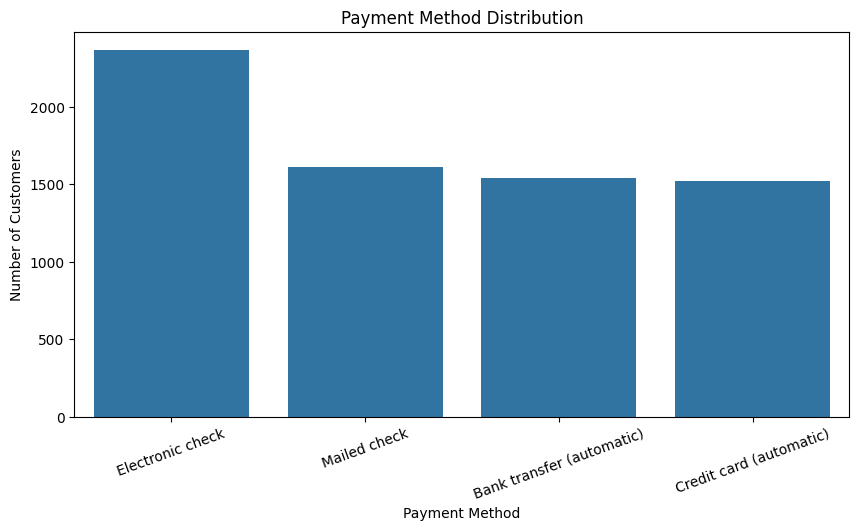

In [136]:
plt.figure(figsize=(10, 5))

sns.countplot(data=data_eda, x="PaymentMethod")

plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.show()

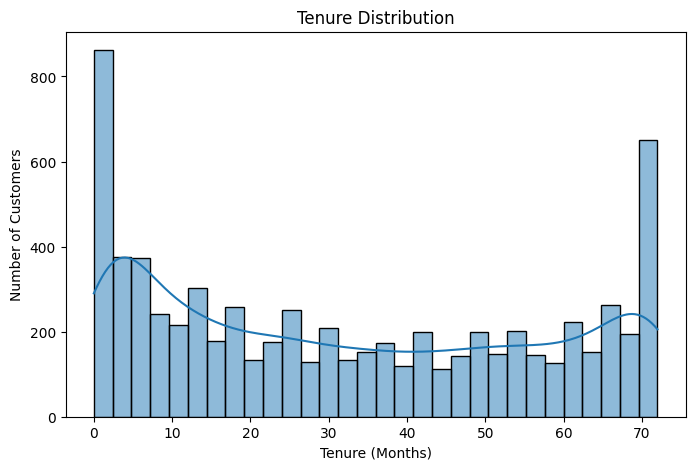

In [137]:
from typing_extensions import dataclass_transform
plt.figure(figsize=(8, 5))

sns.histplot(data=data_eda, x="tenure", bins=30, kde=True)

plt.title("Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

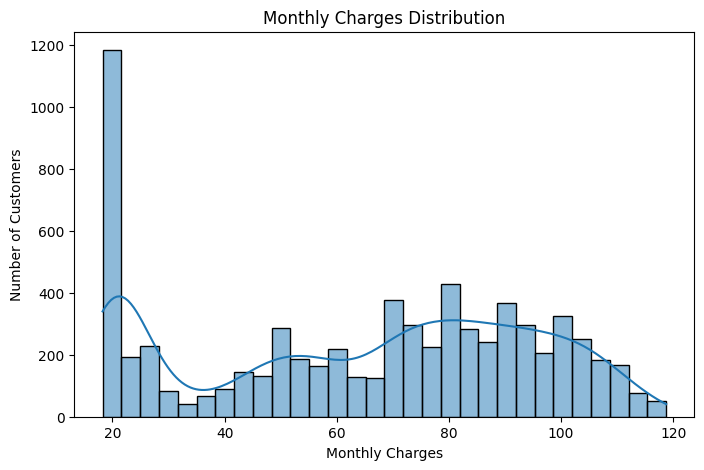

In [138]:
plt.figure(figsize=(8, 5))

sns.histplot(data=data_eda, x="MonthlyCharges", bins=30, kde=True)

plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.show()

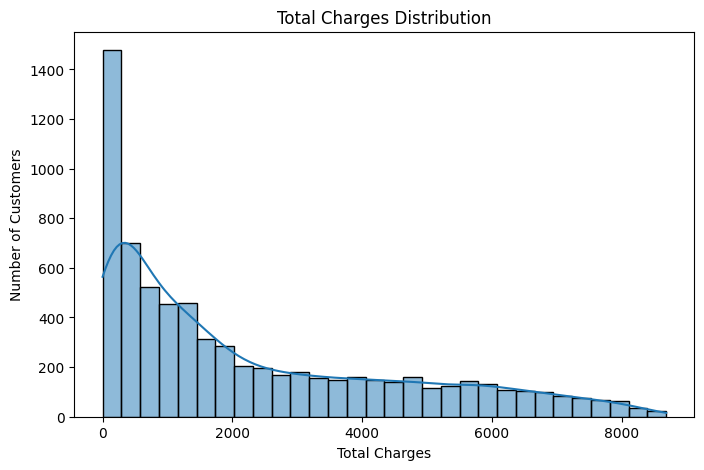

In [139]:
plt.figure(figsize=(8, 5))

sns.histplot(data=data_eda, x="TotalCharges", bins=30, kde=True)

plt.title("Total Charges Distribution")
plt.xlabel("Total Charges")
plt.ylabel("Number of Customers")

plt.show()

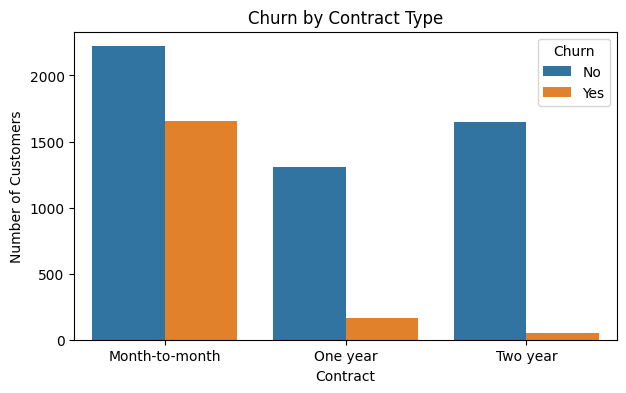

In [140]:
plt.figure(figsize=(7, 4))
sns.countplot(data=data_eda, x="Contract", hue="Churn")

plt.title("Churn by Contract Type")
plt.xlabel("Contract")
plt.ylabel("Number of Customers")
plt.show()

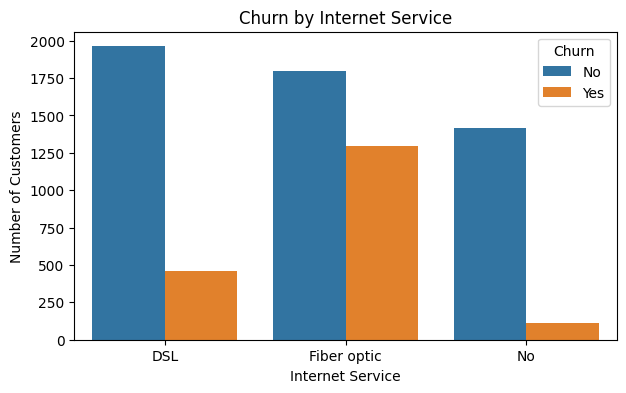

In [141]:
plt.figure(figsize=(7, 4))
sns.countplot(data=data_eda, x="InternetService", hue="Churn")

plt.title("Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.show()

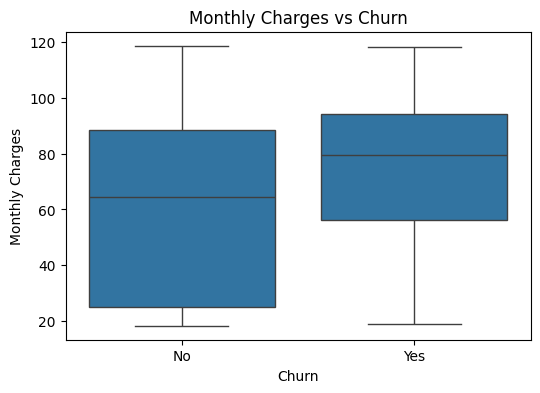

In [142]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=data_eda, x="Churn", y="MonthlyCharges")

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

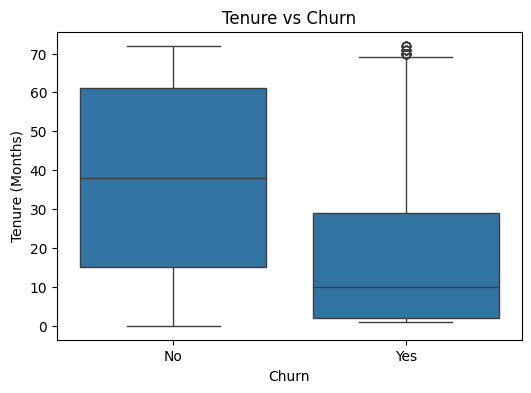

In [143]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=data_eda, x="Churn", y="tenure")

plt.title("Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()

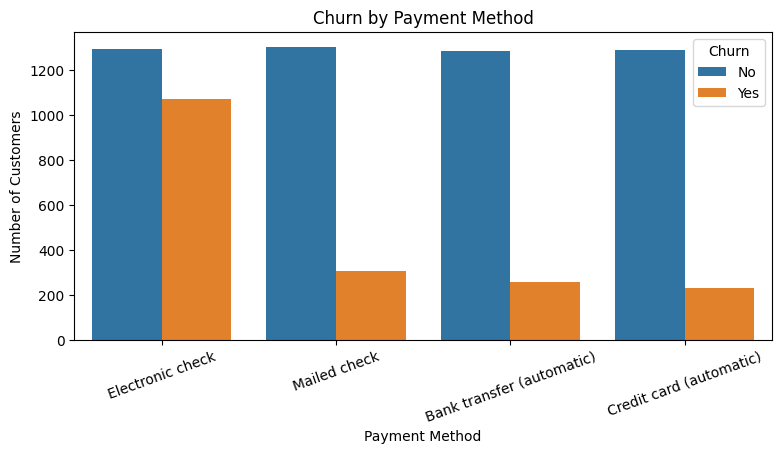

In [144]:
plt.figure(figsize=(9, 4))
sns.countplot(data=data_eda, x="PaymentMethod", hue="Churn")

plt.title("Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.show()

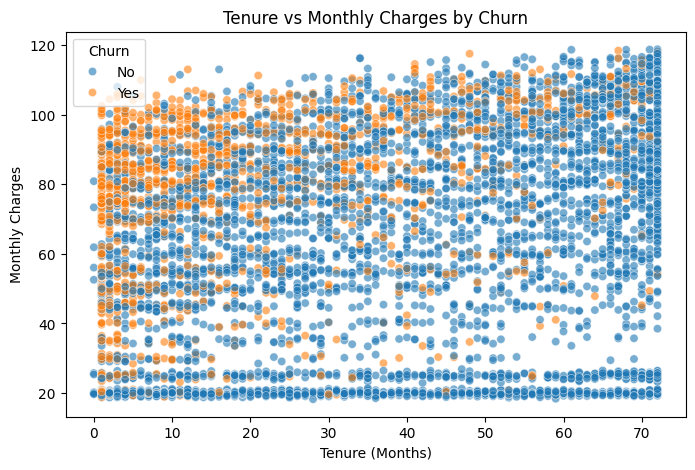

In [145]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=data_eda,
    x="tenure",
    y="MonthlyCharges",
    hue="Churn",
    alpha=0.6
)

plt.title("Tenure vs Monthly Charges by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Monthly Charges")
plt.show()

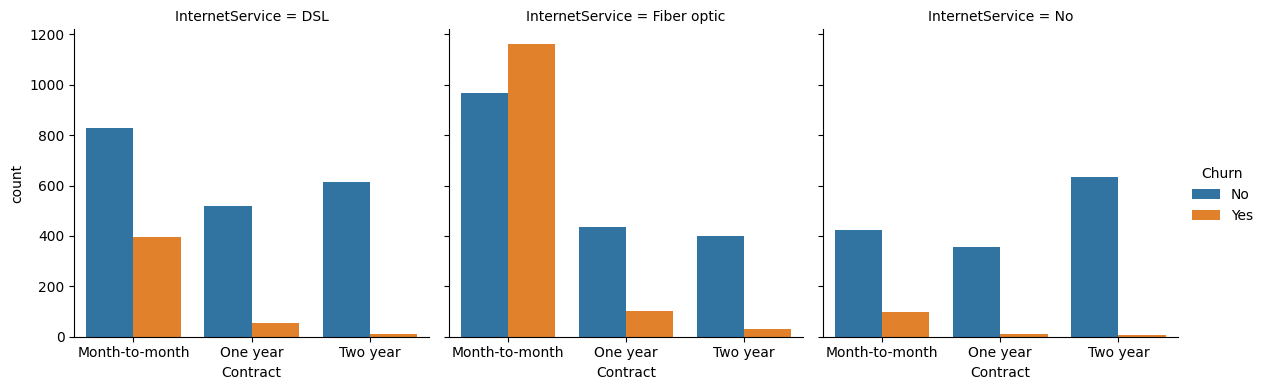

In [146]:
sns.catplot(
    data=data_eda,
    x="Contract",
    hue="Churn",
    col="InternetService",
    kind="count",
    height=4,
    aspect=1
)

plt.show()

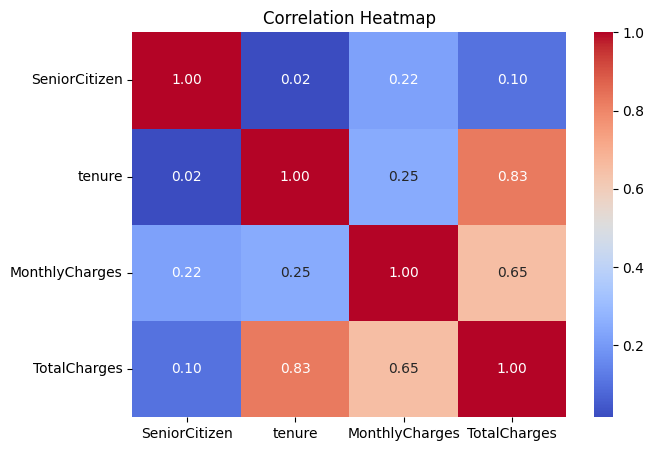

In [147]:
numeric_cols = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]

plt.figure(figsize=(7, 5))

sns.heatmap(
    data_eda[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [148]:
data_model = cleaned_data.copy()

In [149]:
data_model = data_model.drop(columns=["customerID"])

In [150]:
data_model.shape

(7043, 20)

In [151]:
data_model["TenureType"] = pd.cut(
    data_model["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=["New", "Short-term", "Medium-term", "Long-term"]
)

In [152]:
data_model[["tenure", "TenureType"]].head(10)

,tenure,TenureType
0,1,New
1,34,Medium-term
2,2,New
3,45,Medium-term
4,2,New
5,8,New
6,22,Short-term
7,10,New
8,28,Medium-term
9,62,Long-term


In [153]:
service_cols = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

data_model["NumServices"] = (
    data_model[service_cols]
    .apply(lambda row: (row == "Yes").sum(), axis=1)
)

In [154]:
data_model[["NumServices", "Churn"]].head(20)

,NumServices,Churn
0,1,No
1,2,No
2,2,Yes
3,3,No
4,0,Yes
5,3,Yes
6,2,No
7,1,No
8,4,Yes
9,2,No


In [155]:
data_model["AvgMonthlyCharges"] = np.where(
    data_model["tenure"] > 0,
    data_model["TotalCharges"] / data_model["tenure"],
    data_model["MonthlyCharges"]
)

In [156]:
data_model[[
    "tenure",
    "TenureType",
    "NumServices",
    "MonthlyCharges",
    "TotalCharges",
    "AvgMonthlyCharges",
    "Churn"
]].head()

,tenure,TenureType,NumServices,MonthlyCharges,TotalCharges,AvgMonthlyCharges,Churn
0,1,New,1,29.85,29.85,29.850000,No
1,34,Medium-term,2,56.95,1889.50,55.573529,No
2,2,New,2,53.85,108.15,54.075000,Yes
3,45,Medium-term,3,42.30,1840.75,40.905556,No
4,2,New,0,70.70,151.65,75.825000,Yes


In [157]:
data_model.shape

(7043, 23)

In [158]:
X = data_model.drop(columns=["Churn"])
y = data_model["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [159]:
y.value_counts()

,count
Churn,
0,5174
1,1869


In [160]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [161]:
numeric_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "NumServices",
    "AvgMonthlyCharges"
]

In [162]:
categorical_features = [
    col for col in X.columns
    if col not in numeric_features
]

In [163]:
print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'NumServices', 'AvgMonthlyCharges']

Categorical Features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureType']


In [164]:
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

In [165]:
categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

In [166]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [167]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [168]:
print("X_train original shape:", X_train.shape)
print("X_train processed shape:", X_train_processed.shape)

print("X_test original shape:", X_test.shape)
print("X_test processed shape:", X_test_processed.shape)

X_train original shape: (5634, 22)
X_train processed shape: (5634, 51)
X_test original shape: (1409, 22)
X_test processed shape: (1409, 51)


In [169]:
feature_names = preprocessor.get_feature_names_out()

print(feature_names)

['num__SeniorCitizen' 'num__tenure' 'num__MonthlyCharges'
 'num__TotalCharges' 'num__NumServices' 'num__AvgMonthlyCharges'
 'cat__gender_Female' 'cat__gender_Male' 'cat__Partner_No'
 'cat__Partner_Yes' 'cat__Dependents_No' 'cat__Dependents_Yes'
 'cat__PhoneService_No' 'cat__PhoneService_Yes' 'cat__MultipleLines_No'
 'cat__MultipleLines_No phone service' 'cat__MultipleLines_Yes'
 'cat__InternetService_DSL' 'cat__InternetService_Fiber optic'
 'cat__InternetService_No' 'cat__OnlineSecurity_No'
 'cat__OnlineSecurity_No internet service' 'cat__OnlineSecurity_Yes'
 'cat__OnlineBackup_No' 'cat__OnlineBackup_No internet service'
 'cat__OnlineBackup_Yes' 'cat__DeviceProtection_No'
 'cat__DeviceProtection_No internet service' 'cat__DeviceProtection_Yes'
 'cat__TechSupport_No' 'cat__TechSupport_No internet service'
 'cat__TechSupport_Yes' 'cat__StreamingTV_No'
 'cat__StreamingTV_No internet service' 'cat__StreamingTV_Yes'
 'cat__StreamingMovies_No' 'cat__StreamingMovies_No internet service'
 'cat

In [170]:
logreg_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

logreg_model.fit(X_train_processed, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [171]:
y_pred_logreg = logreg_model.predict(X_test_processed)

y_prob_logreg = logreg_model.predict_proba(X_test_processed)[:, 1]

In [172]:
def evaluate_model(model_name, y_true, y_pred, y_prob):
    print(f"===== {model_name} =====")

    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))
    print("ROC-AUC  :", roc_auc_score(y_true, y_prob))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

In [173]:
evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_logreg,
    y_prob_logreg
)

===== Logistic Regression =====
Accuracy : 0.7331440738112136
Precision: 0.4983164983164983
Recall   : 0.7914438502673797
F1 Score : 0.6115702479338843
ROC-AUC  : 0.8420031517218218

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1035
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.80      0.73      0.75      1409



In [174]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train_processed, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)

In [175]:
y_pred_rf = rf_model.predict(X_test_processed)

y_prob_rf = rf_model.predict_proba(X_test_processed)[:, 1]

In [176]:
evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf,
    y_prob_rf
)

===== Random Forest =====
Accuracy : 0.7799858055358411
Precision: 0.6111111111111112
Recall   : 0.47058823529411764
F1 Score : 0.5317220543806647
ROC-AUC  : 0.8219238420005684

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1035
           1       0.61      0.47      0.53       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409



In [177]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_logreg),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_logreg),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_logreg),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_logreg),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_logreg),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.733144,0.498316,0.791444,0.611570,0.842003
1,Random Forest,0.779986,0.611111,0.470588,0.531722,0.821924


In [178]:
results.sort_values(
    by="Recall",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.733144,0.498316,0.791444,0.611570,0.842003
1,Random Forest,0.779986,0.611111,0.470588,0.531722,0.821924


In [179]:
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"],
    "class_weight": [None, "balanced"]
}

In [180]:
grid_search = GridSearchCV(
    LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

In [181]:
grid_search.fit(X_train_processed, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000, random_state=42),
             n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'class_weight': [None, 'balanced'],
                         'solver': ['liblinear', 'lbfgs']},
             scoring='f1')

In [182]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(grid_search.best_score_)

Best Parameters:
{'C': 0.01, 'class_weight': 'balanced', 'solver': 'lbfgs'}

Best Cross-Validation F1 Score:
0.6324662921256705


In [183]:
best_logreg = grid_search.best_estimator_

In [184]:
print(best_logreg)

LogisticRegression(C=0.01, class_weight='balanced', max_iter=1000,
                   random_state=42)


In [185]:
y_pred_best = best_logreg.predict(X_test_processed)

y_prob_best = best_logreg.predict_proba(X_test_processed)[:, 1]

In [186]:
evaluate_model(
    "Tuned Logistic Regression",
    y_test,
    y_pred_best,
    y_prob_best
)

===== Tuned Logistic Regression =====
Accuracy : 0.7444996451383961
Precision: 0.5122377622377622
Recall   : 0.7834224598930482
F1 Score : 0.6194503171247357
ROC-AUC  : 0.8404453744607197

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1035
           1       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



In [187]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Tuned Logistic Regression"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_logreg),
        accuracy_score(y_test, y_pred_best)
    ],
    "Precision": [
        precision_score(y_test, y_pred_logreg),
        precision_score(y_test, y_pred_best)
    ],
    "Recall": [
        recall_score(y_test, y_pred_logreg),
        recall_score(y_test, y_pred_best)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_logreg),
        f1_score(y_test, y_pred_best)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_logreg),
        roc_auc_score(y_test, y_prob_best)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.733144,0.498316,0.791444,0.61157,0.842003
1,Tuned Logistic Regression,0.744500,0.512238,0.783422,0.61945,0.840445


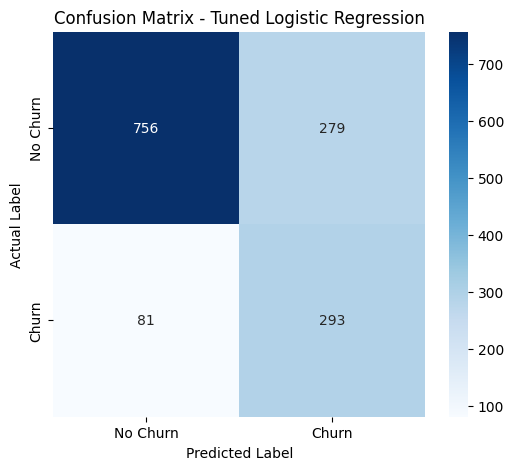

In [188]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Tuned Logistic Regression")

plt.show()

<Figure size 700x600 with 0 Axes>

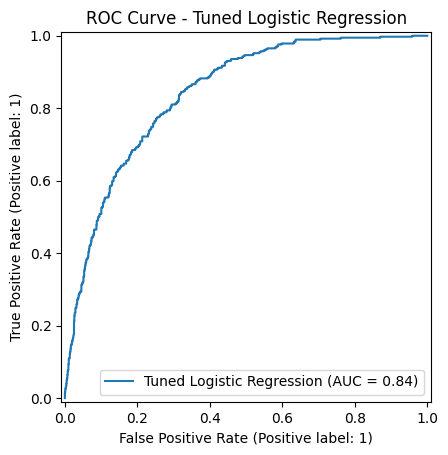

In [189]:
plt.figure(figsize=(7, 6))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_best,
    name="Tuned Logistic Regression"
)

plt.title("ROC Curve - Tuned Logistic Regression")
plt.show()

In [190]:
cm = confusion_matrix(y_test, y_pred_best)

TN, FP, FN, TP = cm.ravel()

specificity = TN / (TN + FP)

print(f"Specificity: {specificity:.2%}")

Specificity: 73.04%


In [191]:
print("Accuracy   :", accuracy_score(y_test, y_pred_best))
print("Precision  :", precision_score(y_test, y_pred_best))
print("Recall     :", recall_score(y_test, y_pred_best))
print("F1 Score   :", f1_score(y_test, y_pred_best))
print("ROC-AUC    :", roc_auc_score(y_test, y_prob_best))
print("Specificity:", specificity)

Accuracy   : 0.7444996451383961
Precision  : 0.5122377622377622
Recall     : 0.7834224598930482
F1 Score   : 0.6194503171247357
ROC-AUC    : 0.8404453744607197
Specificity: 0.7304347826086957


In [192]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Tuned Logistic Regression"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_logreg),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_best)
    ],
    "Precision": [
        precision_score(y_test, y_pred_logreg),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_best)
    ],
    "Recall": [
        recall_score(y_test, y_pred_logreg),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_best)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_logreg),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_best)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_logreg),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_best)
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.733144,0.498316,0.791444,0.611570,0.842003
1,Random Forest,0.779986,0.611111,0.470588,0.531722,0.821924
2,Tuned Logistic Regression,0.744500,0.512238,0.783422,0.619450,0.840445


In [193]:
final_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

In [194]:
param_grid_final = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__solver": ["liblinear", "lbfgs"],
    "model__class_weight": [None, "balanced"]
}

In [195]:
final_grid = GridSearchCV(
    estimator=final_pipeline,
    param_grid=param_grid_final,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

final_grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         ['SeniorCitizen',
                                                                          'tenure',
                                                                          'MonthlyCharges',
                                                                          'TotalCharges',
                                                                          'NumServices',
                                                                          'AvgMonthlyCharges']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         ['gender',
                                                                          'Partn...
                                                                          'OnlineBackup',
                                                                          'DeviceProtection',
                                                                          'TechSupport',
                                                                          'StreamingTV',
                                                                          'StreamingMovies',
                                                                          'Contract',
                                                                          'PaperlessBilling',
                                                                          'PaymentMethod',
                                                                          'TenureType'])])),
                                       ('model',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'model__C': [0.01, 0.1, 1, 10, 100],
                         'model__class_weight': [None, 'balanced'],
                         'model__solver': ['liblinear', 'lbfgs']},
             scoring='f1')

In [196]:
print("Best Parameters:")
print(final_grid.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(final_grid.best_score_)

Best Parameters:
{'model__C': 0.01, 'model__class_weight': 'balanced', 'model__solver': 'lbfgs'}

Best Cross-Validation F1 Score:
0.632676870650314


In [197]:
final_model = final_grid.best_estimator_

In [198]:
y_pred_final = final_model.predict(X_test)

y_prob_final = final_model.predict_proba(X_test)[:, 1]

In [199]:
evaluate_model(
    "Final Tuned Logistic Regression",
    y_test,
    y_pred_final,
    y_prob_final
)

===== Final Tuned Logistic Regression =====
Accuracy : 0.7444996451383961
Precision: 0.5122377622377622
Recall   : 0.7834224598930482
F1 Score : 0.6194503171247357
ROC-AUC  : 0.8404453744607197

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1035
           1       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



In [200]:
cm_final = confusion_matrix(y_test, y_pred_final)

TN, FP, FN, TP = cm_final.ravel()

specificity_final = TN / (TN + FP)

print(f"Specificity: {specificity_final:.2%}")

Specificity: 73.04%


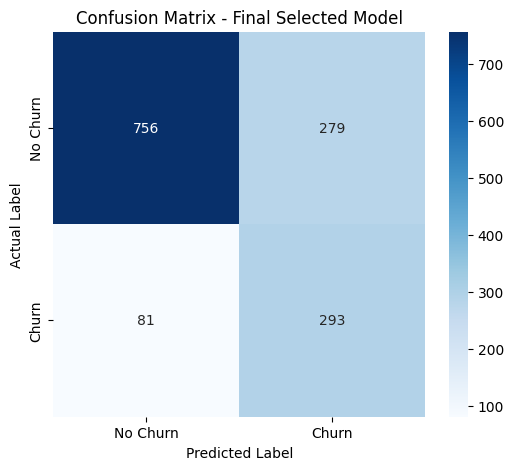

In [201]:
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Final Selected Model")

plt.show()

In [202]:
joblib.dump(final_model, "customer_churn_model.pkl")

['customer_churn_model.pkl']